In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

from setting_for_sda.path_setting import path_list
from setting_for_sda.date_setting import Date_Setting


import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from lib.visualization.distribution_collector import collect_top_mid_bottom_tags
from matplotlib import pyplot as plt
from lib.visualization.plot_generator import PlotGen

import matplotlib as mpl
import lib.visualization.font_setting as font_setting
mpl.rcParams['font.family'] = font_setting.init_font()




Helvetica /home/mghan/.fonts/Helvetica/Helvetica Oblique.ttf
Registered font name: Helvetica


In [2]:
plotgen = PlotGen()

In [ ]:
def draw_bar_plot_for_tag(idx_num, proportion_dict, option_dict, output_dir):
    sharey = False ## 또는 sharey=False
    sharex = True ## 또는 sharex=False

    fig, axs = mpl.pyplot.subplots(1, 2, figsize = (24, 6), constrained_layout=True)
    alpha_list = [0.6, 0.5]
    color_list = ["#a6d96a", "#1a9850"]
    panel_list = ['A.', 'B.', 'C.', 'D.']

    for idx, (title, proportion) in enumerate(proportion_dict.items()):
        x = list(proportion['rel_week'])
        y = list(proportion['pct_pct'])
        plotgen.draw_tag_bar(axs[idx]
                            , f'{title} for {option_dict["selected_tags"]}' 
                            , x
                            , y
                            , color_list[idx]
                            , alpha_list[idx]
                            , panel_list[idx])
        

    fig.supxlabel("Weeks relative to ChatGPT release", fontsize=22) 
    fig.supylabel('Accumulated tag share', fontsize=22)
    filename = f"{idx_num}_bar_plot_{option_dict['selected_tags']}_{option_dict['model']}_{option_dict['year_range']}.png"
    plt.savefig(
    os.path.join(output_dir, filename),
    dpi=300,
    bbox_inches='tight'
    )
    plt.close(fig)
    

In [4]:
def draw_scatter_line_plot_for_tag(idx_num, proportion_dict, option_dict, output_dir):
    sharey = False ## 또는 sharey=False
    sharex = True ## 또는 sharex=False

    fig, axs = plt.subplots(1, 2, figsize = (24, 6), constrained_layout=True)
    alpha_list = [0.6, 0.5]
    color_list = ["#a6d96a", "#1a9850"]
    panel_list = ['A.', 'B.', 'C.', 'D.']

    for idx, (title, proportion) in enumerate(proportion_dict.items()):
        x = list(proportion['rel_week'])
        y = list(proportion['pct_pct'])
        plotgen.draw_tag_regression(axs[idx]
                                    , f'{title} for {option_dict["selected_tags"]}' 
                                    , x
                                    , y
                                    , color_list[idx]
                                    , alpha_list[idx]
                                    , panel_list[idx])
        

    fig.supxlabel("Weeks relative to ChatGPT release", fontsize=22) 
    fig.supylabel('Accumulated tag share', fontsize=22)
    filename = f"{idx_num}_scatter_plot_{option_dict['selected_tags']}_{option_dict['model']}_{option_dict['year_range']}.png"
    plt.savefig(
    os.path.join(output_dir, filename),
    dpi=300,
    bbox_inches='tight'
    )
    plt.close(fig)


In [5]:
def calculate_agg_func(proportion_dict):
    dict_ = dict()
    for key, df in proportion_dict.items():
        print(key)
        df['rel_month'] = df['rel_week']//12
        result = df.groupby('rel_month')['pct_pct'].agg(mean='mean',std='std',n='count').reset_index()
        result['se'] = result['std'] / np.sqrt(result['n'])
        dict_[key] = result
    return dict_    

In [6]:
chk_dict = dict()
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    print(f'[Start....] drawing figures for {lang} language')
    visualization_target = f'run_id_{100+idx}'
    model_in_run = 'tag'
    viz_dir = f'{path_list["data_root_dir"]}/result/{model_in_run}/{visualization_target}'
    data_dir = f"{viz_dir}/data"
    option_dict = load_json(f"{viz_dir}/option.json")
    output_dir = './fig/'
    date_range = 'Weekly'
    std_date = Date_Setting[option_dict['year_range']]['std_date']

    df = load_df(data_dir, ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])
    df['cdate'] = pd.to_datetime(df['cdate'], format="%Y-%m-%d")
    df['rel_week'] = np.floor((df['cdate']-std_date).dt.days/7)
    proportion_dict = dict()
    proportion_dict = collect_top_mid_bottom_tags(df)
    chk_dict[lang] = calculate_agg_func(proportion_dict)

    # draw_bar_plot_for_tag(idx, proportion_dict, option_dict, output_dir)
    # draw_scatter_line_plot_for_tag(idx, proportion_dict, option_dict, output_dir)
    print(f'[End....] drawing figures for {lang} language')

    

[Start....] drawing figures for python language
Top 20% Tags
Middle 60% Tags
Bottom 20% Tags
[End....] drawing figures for python language
[Start....] drawing figures for javascript language
Top 20% Tags
Middle 60% Tags
Bottom 20% Tags
[End....] drawing figures for javascript language
[Start....] drawing figures for java language
Top 20% Tags
Middle 60% Tags
Bottom 20% Tags
[End....] drawing figures for java language
[Start....] drawing figures for c# language
Top 20% Tags
Middle 60% Tags
Bottom 20% Tags
[End....] drawing figures for c# language
[Start....] drawing figures for c++ language
Top 20% Tags
Middle 60% Tags
Bottom 20% Tags
[End....] drawing figures for c++ language
[Start....] drawing figures for c language
Top 20% Tags
Middle 60% Tags
Bottom 20% Tags
[End....] drawing figures for c language
[Start....] drawing figures for r language
Top 20% Tags
Middle 60% Tags
Bottom 20% Tags
[End....] drawing figures for r language
[Start....] drawing figures for php language
Top 20% Tags

In [7]:
chk_dict

{'python': {'Top 20% Tags':     rel_month      mean       std   n        se
  0        -9.0  0.956579  0.002298   8  0.000813
  1        -8.0  0.956701  0.001175  12  0.000339
  2        -7.0  0.957039  0.002183  12  0.000630
  3        -6.0  0.956512  0.003054  12  0.000882
  4        -5.0  0.956259  0.002000  12  0.000577
  5        -4.0  0.954372  0.002827  12  0.000816
  6        -3.0  0.954351  0.002663  12  0.000769
  7        -2.0  0.954766  0.002409  12  0.000695
  8        -1.0  0.953456  0.003755  12  0.001084
  9         0.0  0.942334  0.004393  12  0.001268
  10        1.0  0.929331  0.006345  12  0.001832
  11        2.0  0.920389  0.003749  12  0.001082
  12        3.0  0.915060  0.003069  12  0.000886
  13        4.0  0.910289  0.009470  12  0.002734
  14        5.0  0.907152  0.008105  12  0.002340
  15        6.0  0.899884  0.005179  12  0.001495
  16        7.0  0.893602  0.009463  12  0.002732
  17        8.0  0.887538  0.010915  12  0.003151
  18        9.0  0.86744

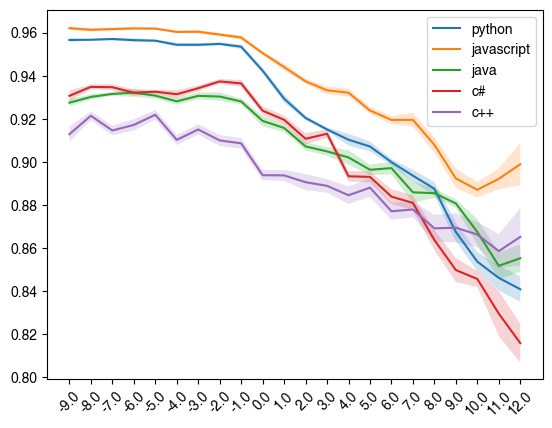

In [10]:
for lang, proportion_dict in chk_dict.items():
    if lang in CONSTANTS.languages_from2020to2022[:5]:
        for key, df in proportion_dict.items():
            if key == 'Top 20% Tags' :     
                mpl.pyplot.plot(df['rel_month'].astype(str), df['mean'], label=lang)
                plt.fill_between(
                    df['rel_month'].astype(str),
                    df['mean'] - df['se'],
                    df['mean'] + df['se'],
                    alpha=0.2
                )

plt.legend()
plt.xticks(rotation=45)
plt.show()

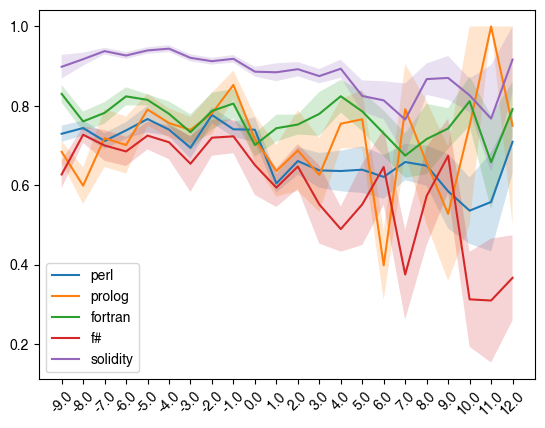

In [11]:
for lang, proportion_dict in chk_dict.items():
    if lang in CONSTANTS.languages_from2020to2022[-5:]:
        for key, df in proportion_dict.items():
            if key == 'Top 20% Tags' :     
                mpl.pyplot.plot(df['rel_month'].astype(str), df['mean'], label=lang)
                plt.fill_between(
                    df['rel_month'].astype(str),
                    df['mean'] - df['se'],
                    df['mean'] + df['se'],
                    alpha=0.2
                )

plt.legend()
plt.xticks(rotation=45)
plt.show()

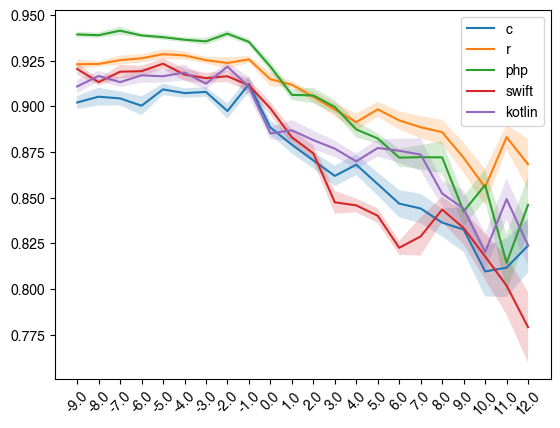

In [12]:
for lang, proportion_dict in chk_dict.items():
    if lang in CONSTANTS.languages_from2020to2022[5:10]:
        for key, df in proportion_dict.items():
            if key == 'Top 20% Tags' :     
                mpl.pyplot.plot(df['rel_month'].astype(str), df['mean'], label=lang)
                plt.fill_between(
                    df['rel_month'].astype(str),
                    df['mean'] - df['se'],
                    df['mean'] + df['se'],
                    alpha=0.2
                )

plt.legend()
plt.xticks(rotation=45)
plt.show()

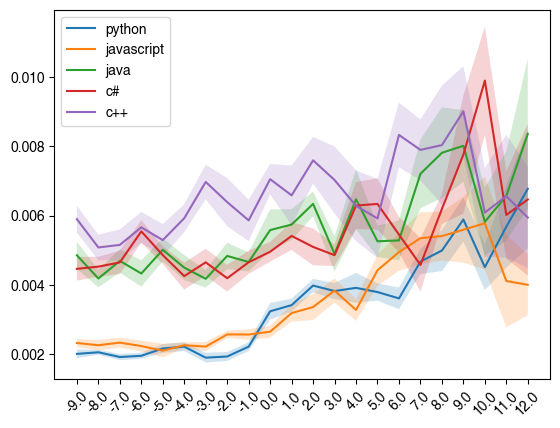

In [14]:
for lang, proportion_dict in chk_dict.items():
    if lang in CONSTANTS.languages_from2020to2022[:5]:
        for key, df in proportion_dict.items():
            if key == 'Bottom 20% Tags' :     
                mpl.pyplot.plot(df['rel_month'].astype(str), df['mean'], label=lang)
                plt.fill_between(
                    df['rel_month'].astype(str),
                    df['mean'] - df['se'],
                    df['mean'] + df['se'],
                    alpha=0.2
                )

plt.legend()
plt.xticks(rotation=45)
plt.show()

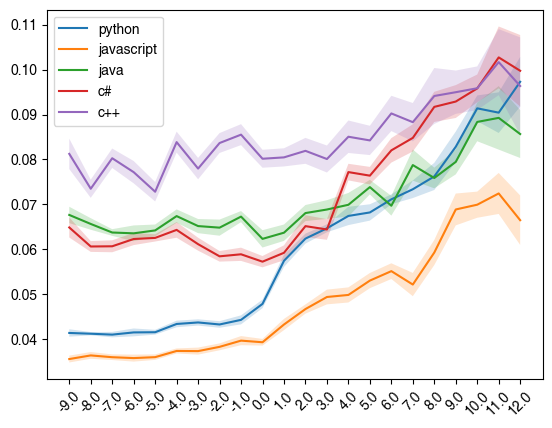

In [21]:
for lang, proportion_dict in chk_dict.items():
    if lang in CONSTANTS.languages_from2020to2022[:5]:
        for key, df in proportion_dict.items():
            if key == 'Middle 60% Tags' :     
                mpl.pyplot.plot(df['rel_month'].astype(str), df['mean'], label=lang)
                plt.fill_between(
                    df['rel_month'].astype(str),
                    df['mean'] - df['se'],
                    df['mean'] + df['se'],
                    alpha=0.2
                )

plt.legend()
plt.xticks(rotation=45)
plt.show()

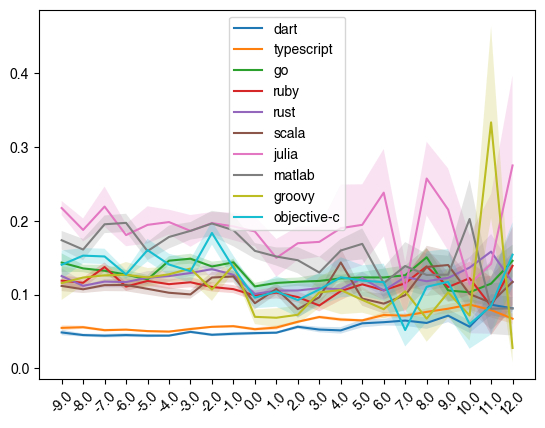

In [20]:
for lang, proportion_dict in chk_dict.items():
    if lang in CONSTANTS.languages_from2020to2022[10:20]:
        for key, df in proportion_dict.items():
            if key == 'Middle 60% Tags' :     
                mpl.pyplot.plot(df['rel_month'].astype(str), df['mean'], label=lang)
                plt.fill_between(
                    df['rel_month'].astype(str),
                    df['mean'] - df['se'],
                    df['mean'] + df['se'],
                    alpha=0.2
                )

plt.legend()
plt.xticks(rotation=45)
plt.show()